# Steps Count for Fitness Journey

Dataset Loading and Exploration

In [2]:
import pandas as pd
df=pd.read_csv('/content/Steps Export_ 3-17-21to9-23-22.csv')

In [3]:
df

,Date,Step Count,Distance Travelled,Active Time,Flights Climbed,Goal,Percentage of Goal Completed,Calories
0,3/17/2021,1500,1.02 km,23:14 min,3,10000,15%,64
1,3/18/2021,3165,2.23 km,44:56 min,2,10000,32%,134
2,3/19/2021,1494,1.08 km,24:51 min,0,10000,15%,68
3,3/20/2021,1808,1.27 km,30:04 min,1,10000,18%,81
4,3/21/2021,2667,1.78 km,30:57 min,3,10000,27%,103
...,...,...,...,...,...,...,...,...
521,9/19/2022,1665,1.14 km,26:09 min,1,3500,48%,72
522,9/20/2022,3676,2.62 km,52:05 min,0,3500,105%,157
523,9/21/2022,444,0.32 km,7:25 min,0,3500,13%,20
524,9/22/2022,506,0.35 km,8:19 min,0,3500,14%,22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date                          526 non-null    object
 1   Step Count                    526 non-null    int64 
 2   Distance Travelled            526 non-null    object
 3   Active Time                   526 non-null    object
 4   Flights Climbed               526 non-null    int64 
 5   Goal                          526 non-null    int64 
 6   Percentage of Goal Completed  526 non-null    object
 7   Calories                      526 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 33.0+ KB


In [5]:
df.describe()

,Step Count,Flights Climbed,Goal,Calories
count,526.000000,526.000000,526.000000,526.000000
mean,3174.403042,0.724335,4229.087452,142.866920
std,2680.441769,1.416252,2053.171745,117.169496
min,0.000000,0.000000,3500.000000,0.000000
25%,1296.750000,0.000000,3500.000000,60.000000
50%,2366.500000,0.000000,3500.000000,108.000000
75%,4369.750000,1.000000,3500.000000,191.000000
max,12432.000000,10.000000,10000.000000,595.000000


In [6]:
df.head()

,Date,Step Count,Distance Travelled,Active Time,Flights Climbed,Goal,Percentage of Goal Completed,Calories
0,3/17/2021,1500,1.02 km,23:14 min,3,10000,15%,64
1,3/18/2021,3165,2.23 km,44:56 min,2,10000,32%,134
2,3/19/2021,1494,1.08 km,24:51 min,0,10000,15%,68
3,3/20/2021,1808,1.27 km,30:04 min,1,10000,18%,81
4,3/21/2021,2667,1.78 km,30:57 min,3,10000,27%,103


In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

import pickle
df = pd.read_csv('/content/Steps Export_ 3-17-21to9-23-22.csv')  # replace with your CSV path
print(df.head())
print(df.describe())

        Date  Step Count Distance Travelled Active Time  Flights Climbed  \
0  3/17/2021        1500            1.02 km   23:14 min                3   
1  3/18/2021        3165            2.23 km   44:56 min                2   
2  3/19/2021        1494            1.08 km   24:51 min                0   
3  3/20/2021        1808            1.27 km   30:04 min                1   
4  3/21/2021        2667            1.78 km   30:57 min                3   

    Goal Percentage of Goal Completed  Calories  
0  10000                          15%        64  
1  10000                          32%       134  
2  10000                          15%        68  
3  10000                          18%        81  
4  10000                          27%       103  
         Step Count  Flights Climbed          Goal    Calories
count    526.000000       526.000000    526.000000  526.000000
mean    3174.403042         0.724335   4229.087452  142.866920
std     2680.441769         1.416252   2053.171745  11

# 2. Data Preprocessing


In [8]:
print(df.isnull().sum())

Date                            0
Step Count                      0
Distance Travelled              0
Active Time                     0
Flights Climbed                 0
Goal                            0
Percentage of Goal Completed    0
Calories                        0
dtype: int64


In [9]:
df.describe()

,Step Count,Flights Climbed,Goal,Calories
count,526.000000,526.000000,526.000000,526.000000
mean,3174.403042,0.724335,4229.087452,142.866920
std,2680.441769,1.416252,2053.171745,117.169496
min,0.000000,0.000000,3500.000000,0.000000
25%,1296.750000,0.000000,3500.000000,60.000000
50%,2366.500000,0.000000,3500.000000,108.000000
75%,4369.750000,1.000000,3500.000000,191.000000
max,12432.000000,10.000000,10000.000000,595.000000


In [10]:
import pandas as pd
import numpy as np

# Convert Active Time to minutes
def convert_time_to_minutes(time_str):
    if pd.isna(time_str):
        return np.nan
    time_str = str(time_str).lower().replace(' ', '')

    # If format is hours
    if 'hr' in time_str:
        time_str = time_str.replace('hr','')
        if ':' in time_str:
            hours, minutes = map(int, time_str.split(':'))
            return hours*60 + minutes
        else:
            return float(time_str) * 60

    # If format is minutes
    if 'min' in time_str:
        time_str = time_str.replace('min','')
        if ':' in time_str:  # e.g., "30:45" => 30 min 45 sec
            minutes, seconds = map(int, time_str.split(':'))
            return minutes + seconds/60
        else:
            return float(time_str)

    return np.nan

# Apply conversion
df['Active Time Minutes'] = df['Active Time'].apply(convert_time_to_minutes)

# Convert 'Distance Travelled' to numeric (remove ' km' and convert to float)
if df['Distance Travelled'].dtype == 'object':
    df['Distance Travelled'] = pd.to_numeric(df['Distance Travelled'].str.replace(' km', '', regex=False), errors='coerce')

# Convert 'Percentage of Goal Completed' to numeric (remove '%' and convert to float)
if df['Percentage of Goal Completed'].dtype == 'object':
    df['Percentage of Goal Completed'] = pd.to_numeric(df['Percentage of Goal Completed'].str.replace('%', '', regex=False), errors='coerce')

# Create calories per active minute
df['calories_per_active_minute'] = df['Calories'] / df['Active Time Minutes']

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


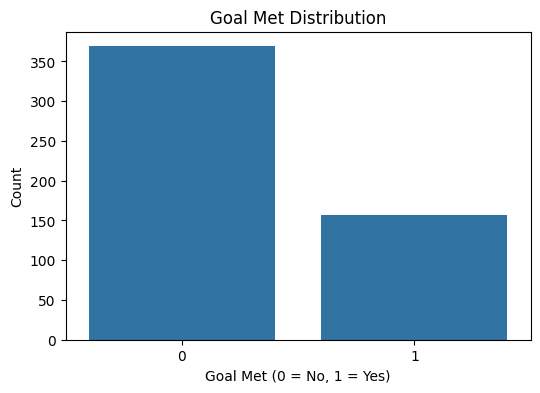

In [12]:
# 1 if step goal met, 0 if not
df['Goal Met'] = (df['Step Count'] >= df['Goal']).astype(int)
#1 means goal achieved and 0 means not
# 2. Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='Goal Met', data=df)
plt.title("Goal Met Distribution")
plt.xlabel("Goal Met (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

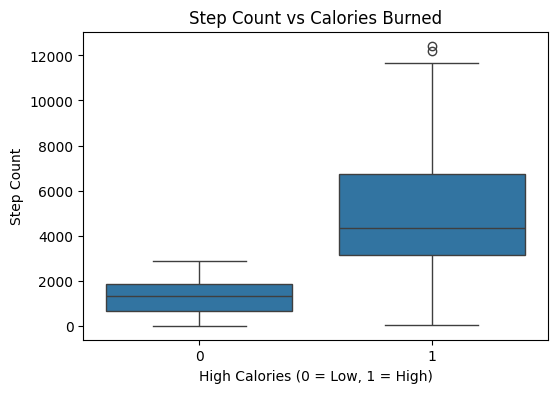

In [13]:
df['High Calories'] = (df['Calories'] >= df['Calories'].median()).astype(int)

plt.figure(figsize=(6,4))
sns.boxplot(x='High Calories', y='Step Count', data=df)
plt.title("Step Count vs Calories Burned")
plt.xlabel("High Calories (0 = Low, 1 = High)")
plt.ylabel("Step Count")
plt.show()

In [14]:
# Handle outliers
numeric_df = df.select_dtypes(include=['int64', 'float64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

print("IQR values:\n", IQR)

df_clean = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
                (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Outlier Removal:", df_clean.shape)

IQR values:
 Step Count                      3073.000000
Distance Travelled                 2.210000
Flights Climbed                    1.000000
Goal                               0.000000
Percentage of Goal Completed      87.500000
Calories                         131.000000
Active Time Minutes               46.291667
calories_per_active_minute         0.252554
Goal Met                           1.000000
High Calories                      1.000000
dtype: float64
Original Shape: (526, 12)
After Outlier Removal: (330, 12)


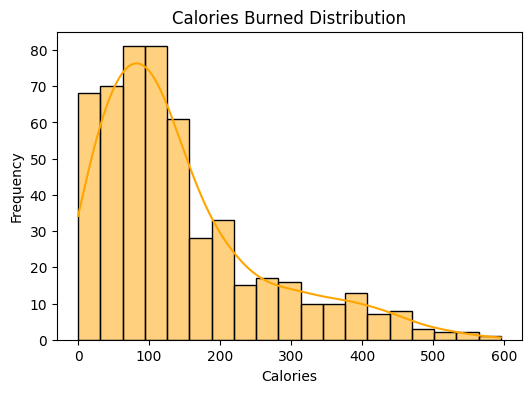

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Calories'], kde=True, color='orange')
plt.title("Calories Burned Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

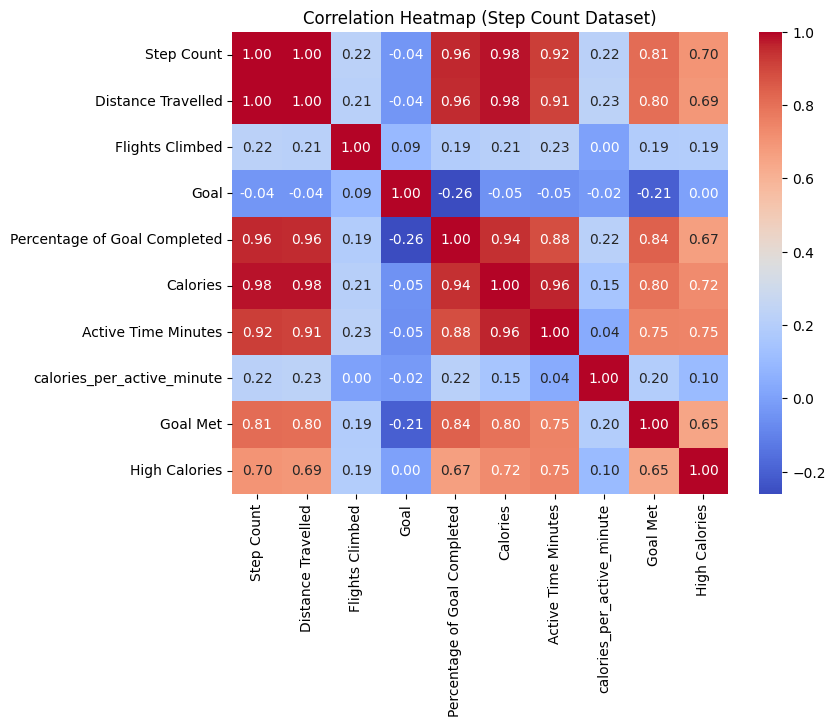

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Step Count Dataset)")
plt.show()

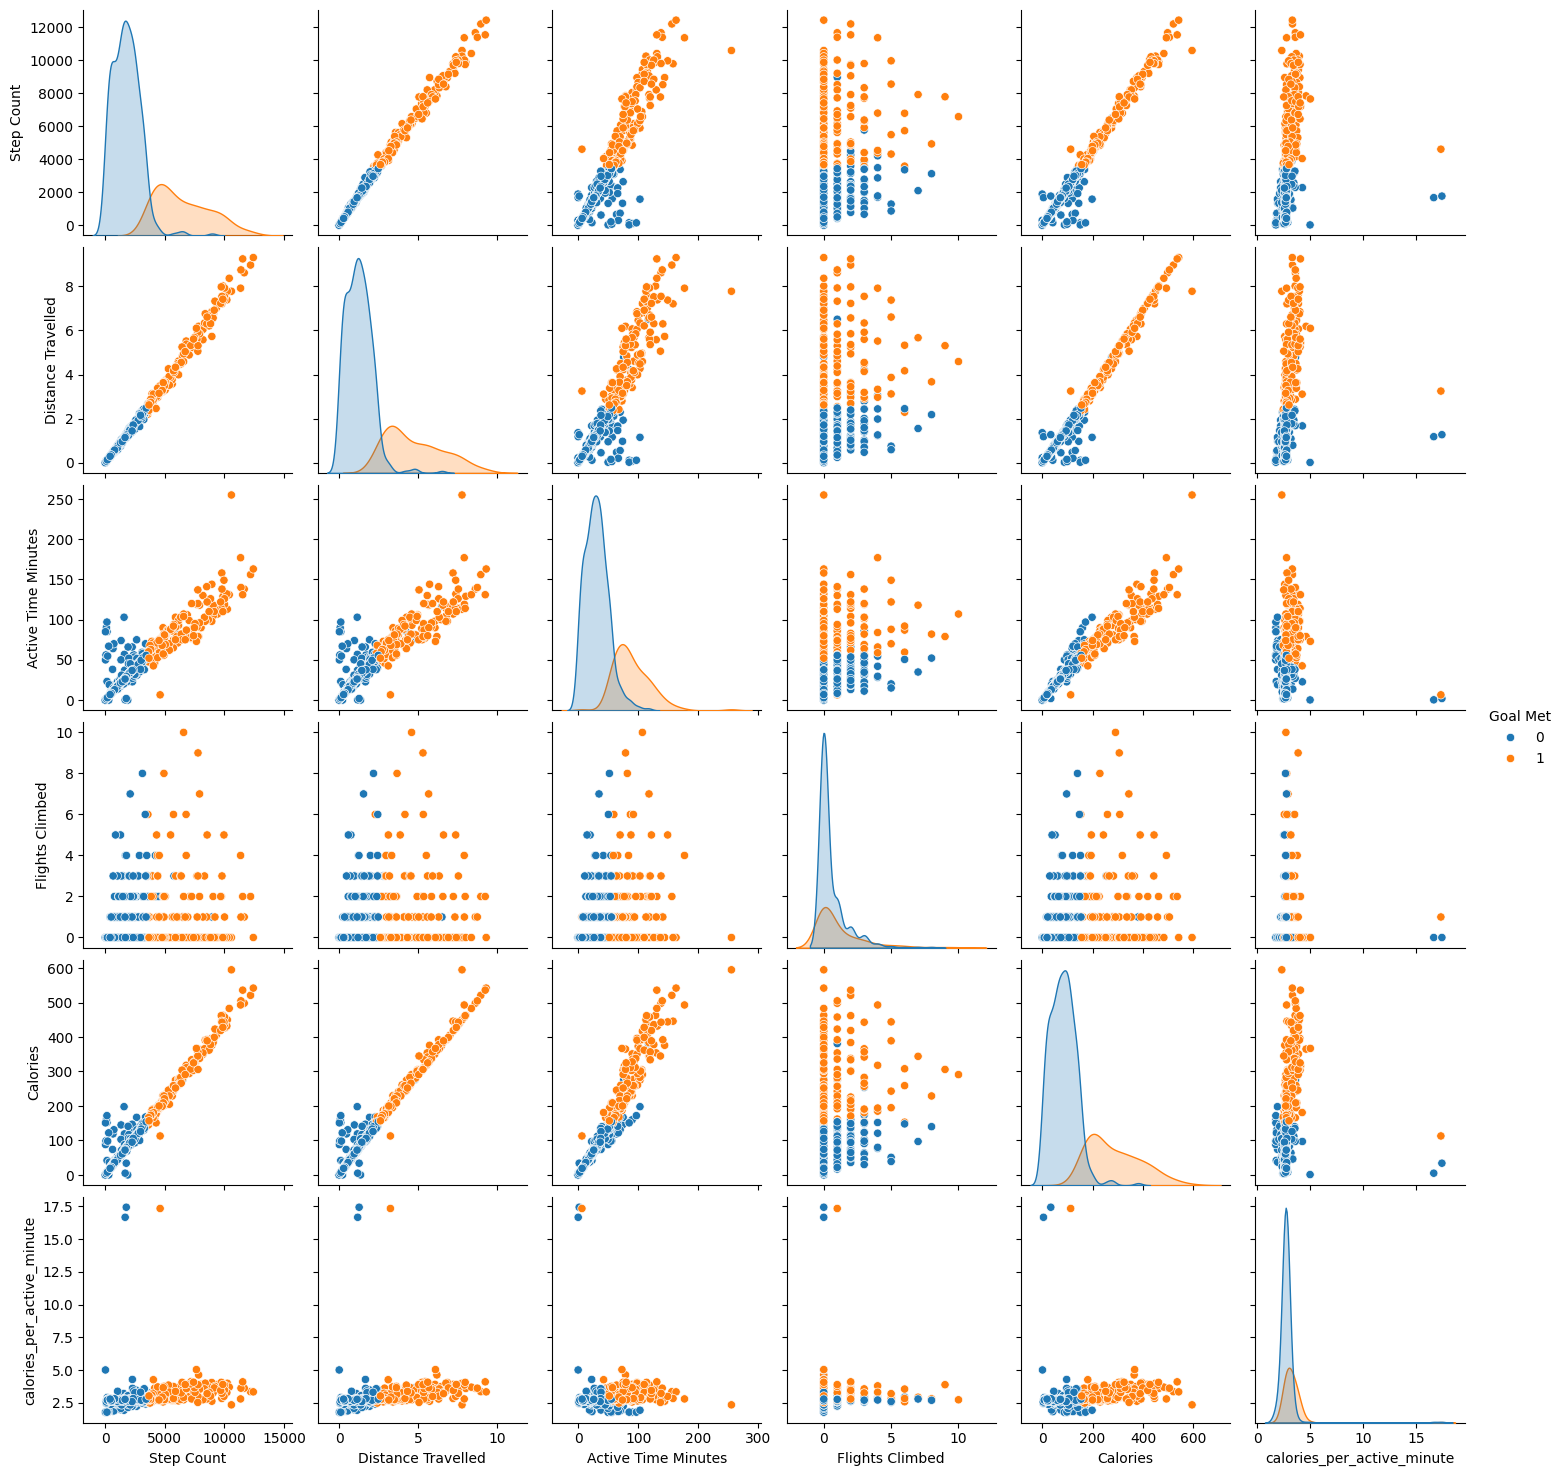

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 'Goal Met' column (0 = No, 1 = Yes)
df['Goal Met'] = (df['Step Count'] >= df['Goal']).astype(int)

# Select columns for pairplot
cols = ['Step Count', 'Distance Travelled', 'Active Time Minutes',
        'Flights Climbed', 'Calories', 'calories_per_active_minute']

# Pairplot
sns.pairplot(df[cols + ['Goal Met']], hue='Goal Met')
plt.show()

# 4. Training Multiple Classification Models

In [18]:
X = df.select_dtypes(include=['int64', 'float64']).drop('Step Count', axis=1)
y = df['Step Count']

In [19]:
# Features (independent variables)
X = df[['Distance Travelled', 'Active Time Minutes', 'Flights Climbed',
        'Calories',  'Goal', 'Percentage of Goal Completed']]

# Target (dependent variable)
y = df['Step Count']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
x_train,x_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [22]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# 5.Performance Evaluation and Model Comparison

In [23]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models={
    'Logistic Regression':LogisticRegression(),
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier(),
    'SVM':SVC(),
    'KNN':KNeighborsClassifier()
}

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [26]:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

/tmp/ipykernel_1599/2454367216.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Empty list to store results
results = []
nan_rows_mask_train = np.isnan(x_train).any(axis=1)
nan_rows_mask_test = np.isnan(x_test).any(axis=1)

x_train_cleaned = x_train[~nan_rows_mask_train]
y_train_cleaned = y_train[~nan_rows_mask_train]

x_test_cleaned = x_test[~nan_rows_mask_test]
y_test_cleaned = y_test[~nan_rows_mask_test]

# --- End of NaN fix ---

# Loop through models
for name, model in models.items():
    # Train model using cleaned data
    model.fit(x_train_cleaned, y_train_cleaned)

    # Prediction
    y_pred = model.predict(x_test_cleaned)
    mae = mean_absolute_error(y_test_cleaned, y_pred)
    mse = mean_squared_error(y_test_cleaned, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_cleaned, y_pred)

    # Append results
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model         MAE           MSE         RMSE  R2 Score
0  Logistic Regression  809.943396  1.125281e+06  1060.792735  0.870919
1        Decision Tree  268.764151  5.470143e+05   739.604159  0.937252
2        Random Forest  169.764151  1.333924e+05   365.229302  0.984699
3                  SVM  664.764151  1.005738e+06  1002.864910  0.884632
4                  KNN  466.603774  5.856854e+05   765.300841  0.932816


In [28]:
#create dataframe
results_df=pd.DataFrame(results)
#display results
print(results_df)

                 Model         MAE           MSE         RMSE  R2 Score
0  Logistic Regression  809.943396  1.125281e+06  1060.792735  0.870919
1        Decision Tree  268.764151  5.470143e+05   739.604159  0.937252
2        Random Forest  169.764151  1.333924e+05   365.229302  0.984699
3                  SVM  664.764151  1.005738e+06  1002.864910  0.884632
4                  KNN  466.603774  5.856854e+05   765.300841  0.932816


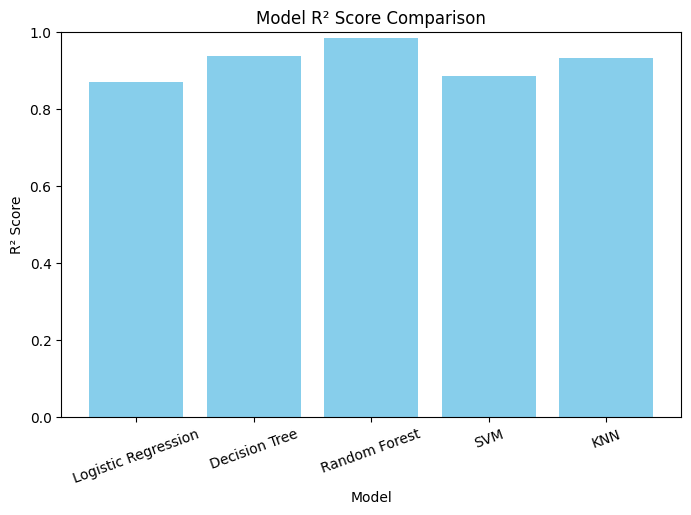

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['R2 Score'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model R² Score Comparison')
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

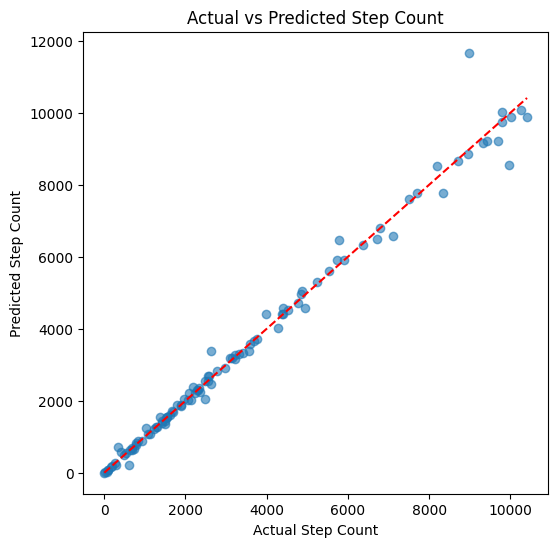

In [30]:
best_model = models['Random Forest']  # or whichever has highest R²
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Step Count")
plt.ylabel("Predicted Step Count")
plt.title("Actual vs Predicted Step Count")
plt.show()

# 6.Best Model Selection

In [31]:
best_model_name=results_df.loc[results_df['R2 Score'].idxmax(),'Model']
print("Best Model:",best_model_name)

Best Model: Random Forest


In [32]:
best_model=RandomForestClassifier()
best_model.fit(x_train,y_train)
pred_rf=best_model.predict(x_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 153.29245283018867
RMSE: 352.106584956617
R2 Score: 0.9857783676079969


In [34]:
import pickle
pickle.dump(best_model,open('stepcount_model.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))

In [35]:
# Example: Step goal = 10,000 steps
y_actual_class = (y_test >= 10000).astype(int)   # 1 = Goal met, 0 = Not met
y_pred_class = (y_pred >= 10000).astype(int)

# 7.GUI Implementation

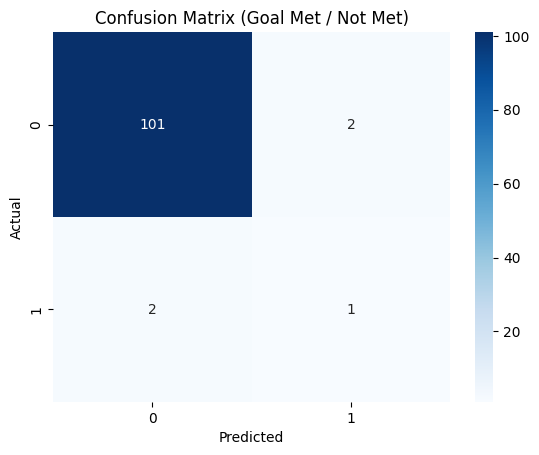

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_actual_class, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Goal Met / Not Met)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
import gradio as gr
import numpy as np
import pickle

# Load your trained regression model and scaler
model = pickle.load(open('stepcount_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

# Prediction function
def predict_step_count(distance, active_time, flights_climbed, calories, goal, perc_goal_completed):
    try:
        # Create input array
        data = np.array([[float(distance), float(active_time), float(flights_climbed),
                          float(calories), float(goal), float(perc_goal_completed)]])

        # Scale features
        data = scaler.transform(data)

        # Predict
        result = model.predict(data)

        return f"Predicted Step Count: {int(result[0])}"

    except Exception as e:
        return f"Error: {str(e)}"

# Create Gradio interface
demo = gr.Interface(
    fn=predict_step_count,
    inputs=[
        gr.Number(label="Distance Travelled (km)"),
        gr.Number(label="Active Time (minutes)"),
        gr.Number(label="Flights Climbed"),
        gr.Number(label="Calories Burned"),
        gr.Number(label="Daily Step Goal"),
        gr.Number(label="% Goal Completed")
    ],
    outputs="text",
    title="Daily Step Count Predictor",
    description="Predict your daily step count based on activity metrics"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cffcee9d071fafd64e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [38]:
from google.colab import files
files.download("/content/scaler.pkl")
files.download("/content/stepcount_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>